# Hugging Face Examples

In [1]:
import torch
import transformers

In [ ]:
# Check out Model Cards! 
# https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
# https://huggingface.co/google-bert/bert-base-uncased
# The BERT model was pretrained on BookCorpus, a dataset consisting of 11,038 unpublished books 
#  and English Wikipedia (excluding lists, tables and headers).

## Basic Usage: The Pipeline

In [3]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

classifier(
    [
        "I love to eat lunch in the park!",
        "I loathe when I eat lunch in the park and drop my food on the ground",
    ]
)

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'POSITIVE', 'score': 0.999754011631012},
 {'label': 'NEGATIVE', 'score': 0.9980241060256958}]

In [ ]:
# Pipelines processing directly from datasets 
# (LONG)

from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
import datasets

pipe = pipeline("text-classification")
dataset = datasets.load_dataset("imdb", name="plain_text", split="unsupervised")

for out in pipe(KeyDataset(dataset, "text"), batch_size=8, truncation="only_first"):
   print(out)


In [6]:
# Process Image Data!

from transformers import pipeline

sourceimage="https://pbs.twimg.com/profile_images/1088174531599106049/wpgUrQfo_400x400.jpg"


vision_classifier = pipeline(model="google/vit-large-patch16-224")
#vision_classifier = pipeline(model="google/vit-base-patch16-224")
preds = vision_classifier(
    images=sourceimage
)
preds = [{"score": round(pred["score"], 4), "label": pred["label"]} for pred in preds]
preds

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

[{'score': 0.8089, 'label': 'sombrero'},
 {'score': 0.0679, 'label': 'Pembroke, Pembroke Welsh corgi'},
 {'score': 0.0362, 'label': 'Cardigan, Cardigan Welsh corgi'},
 {'score': 0.0208, 'label': 'cowboy hat, ten-gallon hat'},
 {'score': 0.0069, 'label': 'Chihuahua'}]

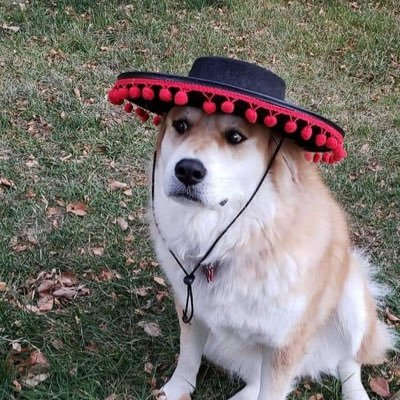

In [5]:
from PIL import Image
import requests
from io import BytesIO

response = requests.get(sourceimage)
img = Image.open(BytesIO(response.content))
  
img

In [8]:
# Process Sound Data!

from transformers import pipeline


#Source : https://audio-samples.github.io/
#sourcefile1="https://audio-samples.github.io/samples/mp3/blizzard_unconditional/sample-2.mp3"

sourcein="https://audio-samples.github.io/samples/mp3/ted_speakers/BillGates/sample-0.mp3"
transcriber = pipeline(model="openai/whisper-base")
transcriber(sourcein)
#transcriber("./sample-2 m.mp3")

{'text': ' The cramp is no small danger on a swim.'}

## Preprocessing

In [13]:
from transformers import AutoTokenizer

checkpoint="distilbert-base-uncased-finetuned-sst-2-english"

tokenizer=AutoTokenizer.from_pretrained(checkpoint)


sequence1="What a lovely day it is today"
sequences=["What a lovely day it is today", 
           "These pretzels are making me thirsty!"]

smodel_1=tokenizer(sequence1)
model_inputs1=tokenizer(sequences)
#model_inputs2=tokenizer(sequences, padding=50)
model_inputs3=tokenizer(sequences, max_length=5, truncation=True)
model_inputs4=tokenizer(sequences, padding=True, return_tensors="pt")

In [ ]:
#Bert, DistilBERT are 512 length

print(len(model_inputs2.get('input_ids')))

In [11]:
print(model_inputs2)

{'input_ids': [[101, 2054, 1037, 8403, 2154, 2009, 2003, 2651, 102], [101, 2122, 3653, 23102, 4877, 2024, 2437, 2033, 24907, 999, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [14]:
print(model_inputs4)

{'input_ids': tensor([[  101,  2054,  1037,  8403,  2154,  2009,  2003,  2651,   102,     0,
             0],
        [  101,  2122,  3653, 23102,  4877,  2024,  2437,  2033, 24907,   999,
           102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [19]:
from transformers import AutoModelForSequenceClassification

model=AutoModelForSequenceClassification.from_pretrained(checkpoint)

output=model(**model_inputs4)

print(output)

SequenceClassifierOutput(loss=None, logits=tensor([[-4.3148,  4.6721],
        [ 0.7525, -0.6070]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


## Models

In [20]:
# Loading a model architecture with weights initialized to random values

from transformers import BertConfig, BertModel

config = BertConfig()

model = BertModel(config)

print(config)

BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.37.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [21]:
#  Load a Pretrained model!

from transformers import BertModel
model = BertModel.from_pretrained("bert-base-cased")
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Automodel Class

In [22]:
#Load AutoModel 

from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"

model = AutoModel.from_pretrained(checkpoint)

outputs = model(**model_inputs4)

print(outputs.last_hidden_state.shape)

torch.Size([2, 11, 768])


In [23]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

outputs = model(**model_inputs4)

print(outputs)

SequenceClassifierOutput(loss=None, logits=tensor([[-4.3148,  4.6721],
        [ 0.7525, -0.6070]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


In [24]:
# Ouputs are raw, unnormalized scores from the last layer of the model

print(outputs.logits.shape)
print(outputs.logits)


torch.Size([2, 2])
tensor([[-4.3148,  4.6721],
        [ 0.7525, -0.6070]], grad_fn=<AddmmBackward0>)


## Post Proccessing

In [ ]:
#  All Transformers models output the logits, as the loss function for training will generally fuse the last activation function, 
# such as SoftMax, with the actual loss function, such as cross entropy
#https://huggingface.co/learn/nlp-course/chapter2/2?fw=pt

In [25]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[1.2503e-04, 9.9987e-01],
        [7.9568e-01, 2.0432e-01]], grad_fn=<SoftmaxBackward0>)


In [26]:
#Print Model Classifications

print(model.config.id2label)

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

{0: 'NEGATIVE', 1: 'POSITIVE'}
tensor([[1.2503e-04, 9.9987e-01],
        [7.9568e-01, 2.0432e-01]], grad_fn=<SoftmaxBackward0>)
